2.19.0
Found extracted folder: /content/dogvscat1000
Total image paths found: 1000
Class balance | cats=500, dogs=500
Loading all images into memory (this is fine for 1000 imgs @ 128x128)...
X shape: (1000, 128, 128, 3) | y shape: (1000,) | input_shape: (128, 128, 3)
Baseline Dense MLP | Fold 1/10 | Test Accuracy: 0.5000
Baseline Dense MLP | Fold 2/10 | Test Accuracy: 0.5200
Baseline Dense MLP | Fold 3/10 | Test Accuracy: 0.5200
Baseline Dense MLP | Fold 4/10 | Test Accuracy: 0.5300
Baseline Dense MLP | Fold 5/10 | Test Accuracy: 0.5300
Baseline Dense MLP | Fold 6/10 | Test Accuracy: 0.5200
Baseline Dense MLP | Fold 7/10 | Test Accuracy: 0.5200
Baseline Dense MLP | Fold 8/10 | Test Accuracy: 0.5300
Baseline Dense MLP | Fold 9/10 | Test Accuracy: 0.4700
Baseline Dense MLP | Fold 10/10 | Test Accuracy: 0.5200

Baseline Dense MLP | 10-Fold Accuracy: [0.5  0.52 0.52 0.53 0.53 0.52 0.52 0.53 0.47 0.52]
Baseline Dense MLP | Mean Acc: 0.5160 | Std: 0.0184


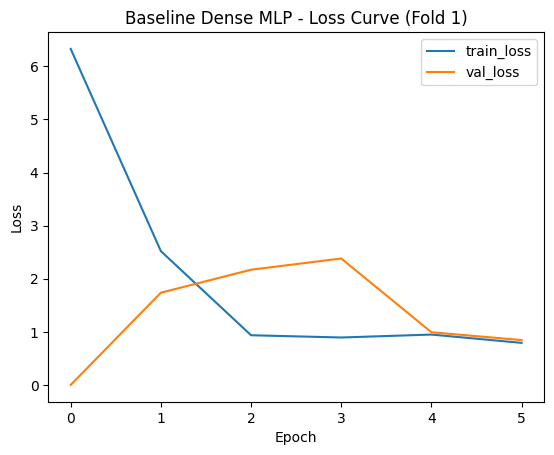

Dense + BatchNorm + Dropout(0.5) | Fold 1/10 | Test Accuracy: 0.6100
Dense + BatchNorm + Dropout(0.5) | Fold 2/10 | Test Accuracy: 0.6400
Dense + BatchNorm + Dropout(0.5) | Fold 3/10 | Test Accuracy: 0.5000
Dense + BatchNorm + Dropout(0.5) | Fold 4/10 | Test Accuracy: 0.5600
Dense + BatchNorm + Dropout(0.5) | Fold 5/10 | Test Accuracy: 0.5600
Dense + BatchNorm + Dropout(0.5) | Fold 6/10 | Test Accuracy: 0.5900
Dense + BatchNorm + Dropout(0.5) | Fold 7/10 | Test Accuracy: 0.5500
Dense + BatchNorm + Dropout(0.5) | Fold 8/10 | Test Accuracy: 0.5200
Dense + BatchNorm + Dropout(0.5) | Fold 9/10 | Test Accuracy: 0.4900
Dense + BatchNorm + Dropout(0.5) | Fold 10/10 | Test Accuracy: 0.5100

Dense + BatchNorm + Dropout(0.5) | 10-Fold Accuracy: [0.61 0.64 0.5  0.56 0.56 0.59 0.55 0.52 0.49 0.51]
Dense + BatchNorm + Dropout(0.5) | Mean Acc: 0.5530 | Std: 0.0495


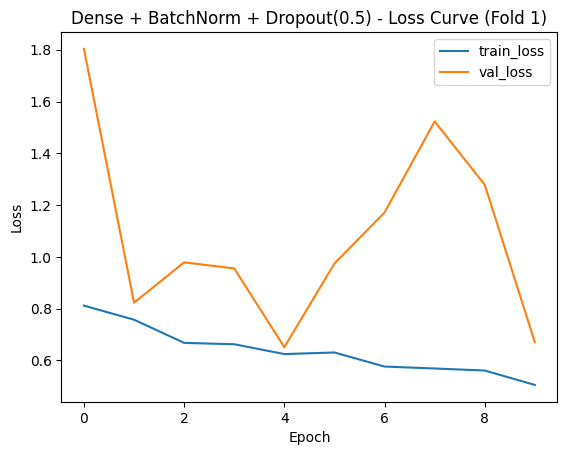

Dense + BatchNorm only | Fold 1/10 | Test Accuracy: 0.5900
Dense + BatchNorm only | Fold 2/10 | Test Accuracy: 0.6100
Dense + BatchNorm only | Fold 3/10 | Test Accuracy: 0.4700
Dense + BatchNorm only | Fold 4/10 | Test Accuracy: 0.6000
Dense + BatchNorm only | Fold 5/10 | Test Accuracy: 0.6000
Dense + BatchNorm only | Fold 6/10 | Test Accuracy: 0.5000
Dense + BatchNorm only | Fold 7/10 | Test Accuracy: 0.5100
Dense + BatchNorm only | Fold 8/10 | Test Accuracy: 0.5600
Dense + BatchNorm only | Fold 9/10 | Test Accuracy: 0.5000
Dense + BatchNorm only | Fold 10/10 | Test Accuracy: 0.5100

Dense + BatchNorm only | 10-Fold Accuracy: [0.59 0.61 0.47 0.6  0.6  0.5  0.51 0.56 0.5  0.51]
Dense + BatchNorm only | Mean Acc: 0.5450 | Std: 0.0523
Dense + Dropout(0.5) only | Fold 1/10 | Test Accuracy: 0.5200
Dense + Dropout(0.5) only | Fold 2/10 | Test Accuracy: 0.5000
Dense + Dropout(0.5) only | Fold 3/10 | Test Accuracy: 0.5200
Dense + Dropout(0.5) only | Fold 4/10 | Test Accuracy: 0.6000
Dense + D

In [ ]:
# CAP 6619 - Homework 2 - Question 7 Programming Task - Noah Russell

# set up out imports
import os, re, pathlib, zipfile, random, numpy as np, matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# upload paths
ZIP_PATH    = "/content/dogvscat1000.zip"
EXTRACT_DIR = "/content/dogvscat1000"
IMG_EXTS    = (".jpg", ".jpeg", ".png")

# image and training parameters
IMG_SIZE   = (128, 128)   # 128x128 gives us bit more signal
CHANNELS   = 3
EPOCHS     = 25           # keeping it slightly higher than 20 because EarlyStopping prevents overfitting
BATCH_SIZE = 32
VAL_SPLIT  = 0.1
PATIENCE   = 5

print(tf.__version__)

# unzipping our files and making it clean
def maybe_unzip(zip_path, extract_dir):
    if not os.path.exists(extract_dir):
        assert os.path.exists(zip_path), f"Zip not found at {zip_path}"
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_dir)
        print(f"Unzipped to: {extract_dir}")
    else:
        print(f"Found extracted folder: {extract_dir}")

maybe_unzip(ZIP_PATH, EXTRACT_DIR)

all_img_paths = []
for root, _, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.lower().endswith(IMG_EXTS):
            all_img_paths.append(os.path.join(root, f))

all_img_paths = sorted(all_img_paths)
print("Total image paths found:", len(all_img_paths))
assert len(all_img_paths) >= 1000, f"Expected ~1000 images, found {len(all_img_paths)}"

# pull from creating subfolder after unzipping
def infer_label_from_path(p):
    p = pathlib.Path(p)
    parent = p.parent.name.lower()
    name   = p.name.lower()

    # explicit class subfolders
    if parent in ('cat', 'cats'): return 0
    if parent in ('dog', 'dogs'): return 1

    # giving file name prefix (Kaggle style)
    if re.match(r'^cat[\W_\.]', name): return 0
    if re.match(r'^dog[\W_\.]', name): return 1

    raise ValueError(f"Cannot infer label from: {p}")

labels = np.array([infer_label_from_path(p) for p in all_img_paths], dtype=np.int32)
num_dogs = int(labels.sum())
num_cats = len(labels) - num_dogs
print(f"Class balance | cats={num_cats}, dogs={num_dogs}")
assert abs(num_cats - num_dogs) <= 10, "Labels look unbalanced—check your folder/file names."

# loading and normalizing our images
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_and_preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)   # PIL image
    arr = img_to_array(img)                         # float32 HxWxC
    arr = arr / 255.0                               # normalize 0..1
    return arr

print("Loading all images into memory (this is fine for 1000 imgs @ 128x128)...")
X = np.stack([load_and_preprocess_image(p) for p in all_img_paths], axis=0).astype(np.float32)
y = labels.astype(np.float32)

input_shape = (IMG_SIZE[0], IMG_SIZE[1], CHANNELS)
print("X shape:", X.shape, "| y shape:", y.shape, "| input_shape:", input_shape)

# our models (dense only)
def build_baseline_model(input_shape):
    # Two hidden layers >= 50 units (dense-only)
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_bn_dropout_model(input_shape, dropout_rate=0.5):
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# additional ablations for separate BN-only / DO-only:
def build_bn_only_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_do_only_model(input_shape, dropout_rate=0.5):
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# training and evaluating with 10-fold CV
def train_evaluate_cv(X, y, model_fn, n_splits=10, label="Model", plot_first_fold_loss=True):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_acc = []
    first_history = None

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = model_fn(input_shape)
        callbacks = [EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)]
        history = model.fit(
            X_train, y_train,
            validation_split=VAL_SPLIT,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=callbacks
        )

        # evaluate on test fold
        y_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(np.int32)
        acc = accuracy_score(y_test, y_pred)
        fold_acc.append(acc)
        print(f"{label} | Fold {fold_idx}/{n_splits} | Test Accuracy: {acc:.4f}")

        if plot_first_fold_loss and first_history is None:
            first_history = history

    fold_acc = np.array(fold_acc)
    mean_acc = fold_acc.mean()
    std_acc  = fold_acc.std(ddof=1) if len(fold_acc) > 1 else 0.0

    print(f"\n{label} | 10-Fold Accuracy: {np.round(fold_acc, 4)}")
    print(f"{label} | Mean Acc: {mean_acc:.4f} | Std: {std_acc:.4f}")

    # plot our first fold's training/validation loss curve
    if first_history is not None:
        plt.figure()
        plt.plot(first_history.history['loss'],     label='train_loss')
        plt.plot(first_history.history['val_loss'], label='val_loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{label} - Loss Curve (Fold 1)')
        plt.legend()
        plt.show()

    return fold_acc, mean_acc, std_acc

# running baseline
baseline_accs, baseline_mean, baseline_std = train_evaluate_cv(
    X, y, build_baseline_model, n_splits=10, label="Baseline Dense MLP", plot_first_fold_loss=True
)

# running Bn and dropout
bn_do_accs, bn_do_mean, bn_do_std = train_evaluate_cv(
    X, y, lambda shape: build_bn_dropout_model(shape, dropout_rate=0.5),
    n_splits=10, label="Dense + BatchNorm + Dropout(0.5)", plot_first_fold_loss=True
)

# run BatchNorm only & Dropout only (separate ablations)
bn_only_accs, bn_only_mean, bn_only_std = train_evaluate_cv(
    X, y, build_bn_only_model,
    n_splits=10,
    label="Dense + BatchNorm only",
    plot_first_fold_loss=False
)

do_only_accs, do_only_mean, do_only_std = train_evaluate_cv(
    X, y, lambda shape: build_do_only_model(shape, dropout_rate=0.5),
    n_splits=10,
    label="Dense + Dropout(0.5) only",
    plot_first_fold_loss=False
)

# === Update the final report printout ===
print("\n========== FINAL 10-FOLD REPORT ==========")
print(f"Baseline Dense MLP             : mean={baseline_mean:.4f}, std={baseline_std:.4f}")
print(f"BN + Dropout(0.5) Variant      : mean={bn_do_mean:.4f},  std={bn_do_std:.4f}")
print(f"BatchNorm only                 : mean={bn_only_mean:.4f}, std={bn_only_std:.4f}")
print(f"Dropout(0.5) only              : mean={do_only_mean:.4f}, std={do_only_std:.4f}")

if bn_do_mean > baseline_mean:
    print("Conclusion: Adding BatchNorm and Dropout improved generalization over the 10 folds.")
elif bn_do_mean < baseline_mean:
    print("Conclusion: In this run, the baseline slightly outperformed the BN/Dropout variant (results can vary).")
else:
    print("Conclusion: Both models achieved similar performance; BN/Dropout still helps regularization/stability.")
